# Credit Risk Dataset - Exploratory Data Analysis (EDA)

## Objective
The objective of this analysis is to understand the dataset structure, identify missing values, analyze feature distributions, and explore relationships between variables to prepare the data for machine learning modeling (Logistic Regression with SMOTE).

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [52]:
df = pd.read_csv("credit_risk_dataset.csv")
df.head()

,Age,Employment_Type,Years_of_Employment,Annual_Income,Savings_Balance,Bank_Balance,Credit_Score,Debt_to_Income_Ratio,Existing_Loans_Count,Loan_Amount_Requested,Loan_Term,Missed_Payments,Num_of_Credit_Inquiries,Credit_Card_Utilization,Residence_Type,Dependents_Count,Default
0,59,Salaried,4.446246,1777465,997150,472726,695,0.47,2,956030,12,0,3,19,Owned,4,0
1,49,Salaried,2.905413,803023,464710,415716,821,0.25,4,747247,24,2,8,83,Rented,1,0
2,35,Self-Employed,4.172893,952318,729992,119360,563,0.28,3,988397,36,5,9,35,Rented,4,0
3,28,Salaried,7.822088,1972508,269580,268894,573,0.32,0,924403,12,0,0,14,Rented,0,0
4,41,Salaried,6.488495,708434,348857,70018,471,0.46,0,498520,12,0,6,95,Owned,2,0


In [53]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      1800 non-null   int64  
 1   Employment_Type          1800 non-null   object 
 2   Years_of_Employment      1800 non-null   float64
 3   Annual_Income            1800 non-null   int64  
 4   Savings_Balance          1800 non-null   int64  
 5   Bank_Balance             1800 non-null   int64  
 6   Credit_Score             1800 non-null   int64  
 7   Debt_to_Income_Ratio     1800 non-null   float64
 8   Existing_Loans_Count     1800 non-null   int64  
 9   Loan_Amount_Requested    1800 non-null   int64  
 10  Loan_Term                1800 non-null   int64  
 11  Missed_Payments          1800 non-null   int64  
 12  Num_of_Credit_Inquiries  1800 non-null   int64  
 13  Credit_Card_Utilization  1800 non-null   int64  
 14  Residence_Type          

In [54]:
df.describe()

,Age,Years_of_Employment,Annual_Income,Savings_Balance,Bank_Balance,Credit_Score,Debt_to_Income_Ratio,Existing_Loans_Count,Loan_Amount_Requested,Loan_Term,Missed_Payments,Num_of_Credit_Inquiries,Credit_Card_Utilization,Dependents_Count,Default
count,1800.000000,1800.000000,1.800000e+03,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1.800000e+03,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000
mean,40.413889,5.027770,1.321380e+06,514859.647222,248443.698889,599.325556,0.499639,1.987778,1.045594e+06,32.986667,2.468333,4.421667,54.298889,2.061667,0.157222
std,11.360842,2.857022,6.926364e+05,290177.278919,140267.572869,175.935895,0.232918,1.409436,5.588968e+05,17.885680,1.713205,2.867750,25.833963,1.460268,0.364111
min,21.000000,0.000000,1.007270e+05,37.000000,5036.000000,300.000000,0.100000,0.000000,5.243800e+04,12.000000,0.000000,0.000000,10.000000,0.000000,0.000000
25%,31.000000,2.961458,7.273282e+05,269555.500000,129285.750000,447.000000,0.300000,1.000000,5.779052e+05,12.000000,1.000000,2.000000,32.000000,1.000000,0.000000
50%,41.000000,4.869333,1.303631e+06,521959.500000,249776.500000,602.000000,0.500000,2.000000,1.041157e+06,36.000000,2.000000,4.000000,54.000000,2.000000,0.000000
75%,50.000000,7.033741,1.930832e+06,765570.000000,360713.000000,752.000000,0.700000,3.000000,1.532770e+06,60.000000,4.000000,7.000000,77.000000,3.000000,0.000000
max,59.000000,14.185841,2.499290e+06,998383.000000,499509.000000,899.000000,0.900000,4.000000,1.999173e+06,60.000000,5.000000,9.000000,99.000000,4.000000,1.000000


In [55]:
df.isnull().sum()

Age                        0
Employment_Type            0
Years_of_Employment        0
Annual_Income              0
Savings_Balance            0
Bank_Balance               0
Credit_Score               0
Debt_to_Income_Ratio       0
Existing_Loans_Count       0
Loan_Amount_Requested      0
Loan_Term                  0
Missed_Payments            0
Num_of_Credit_Inquiries    0
Credit_Card_Utilization    0
Residence_Type             0
Dependents_Count           0
Default                    0
dtype: int64

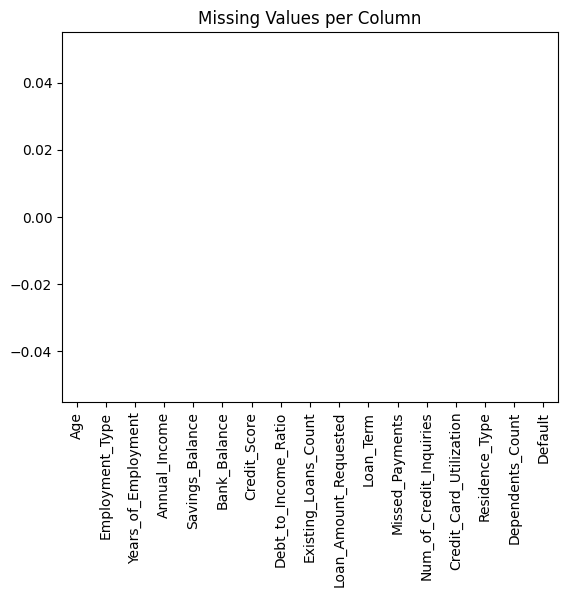

In [56]:
df.isnull().sum().plot(kind='bar')
plt.title("Missing Values per Column")
plt.show()

In [57]:
df['Default'].value_counts()

Default
0    1517
1     283
Name: count, dtype: int64

In [58]:
df['Default'].value_counts(normalize=True) * 100

Default
0    84.277778
1    15.722222
Name: proportion, dtype: float64

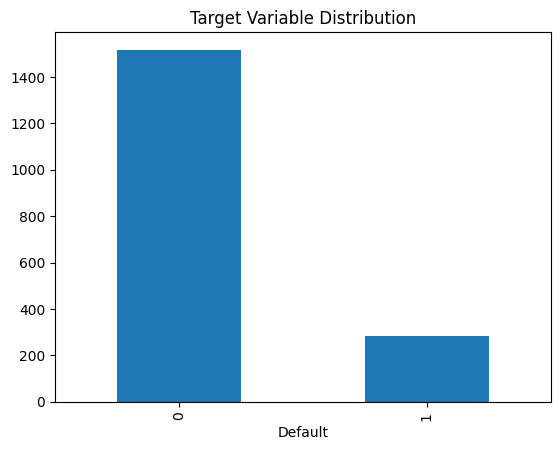

In [59]:
df['Default'].value_counts().plot(kind='bar')
plt.title("Target Variable Distribution")
plt.show()

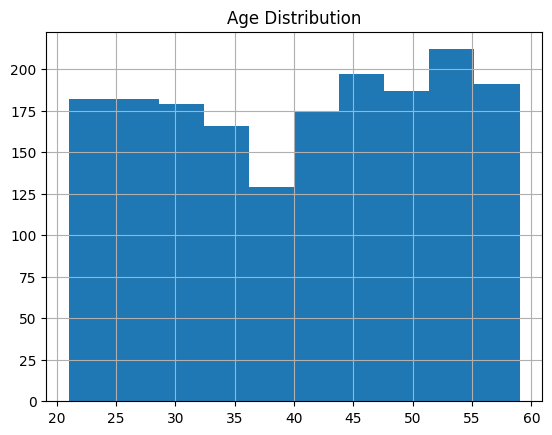

In [60]:
df['Age'].hist()
plt.title("Age Distribution")
plt.show()

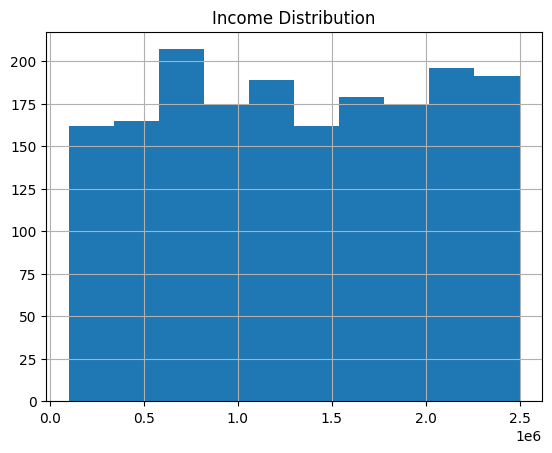

In [61]:
df['Annual_Income'].hist()
plt.title("Income Distribution")
plt.show()

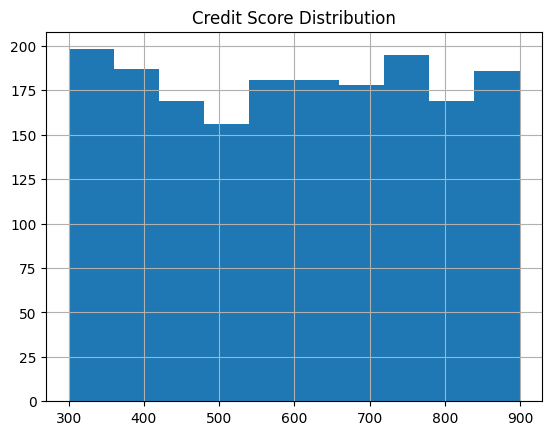

In [62]:
df['Credit_Score'].hist()
plt.title("Credit Score Distribution")
plt.show()

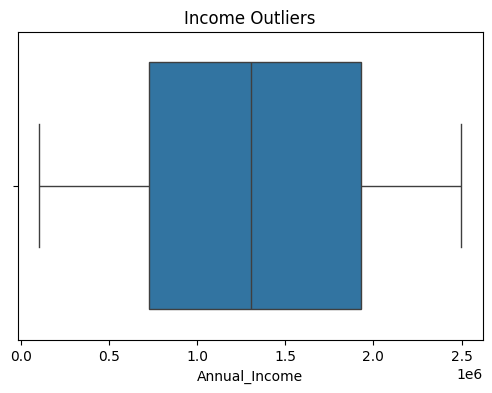

In [63]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Annual_Income'])
plt.title("Income Outliers")
plt.show()

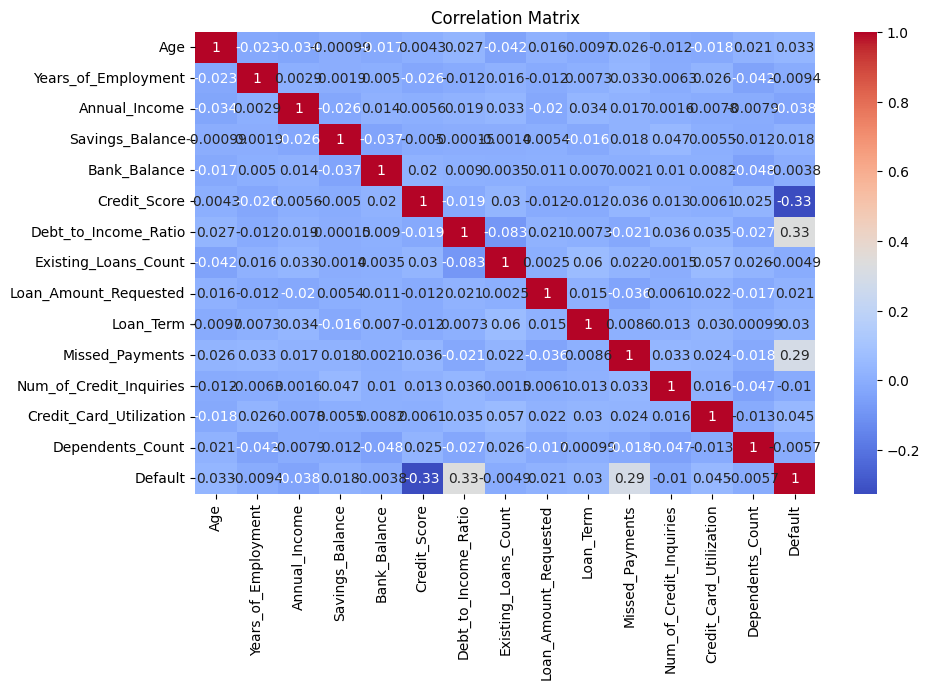

In [64]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

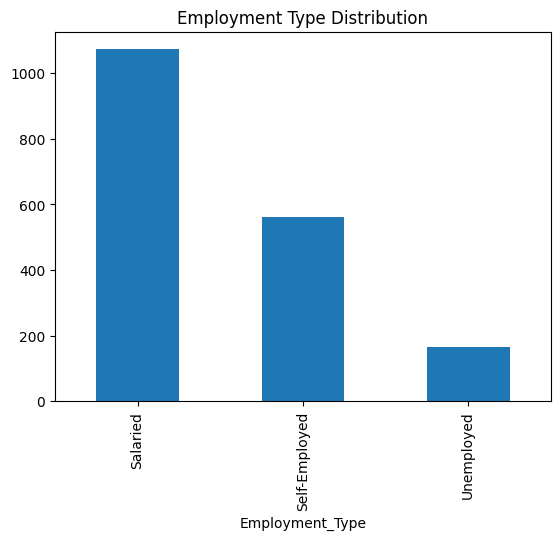

In [65]:
df['Employment_Type'].value_counts().plot(kind='bar')
plt.title("Employment Type Distribution")
plt.show()

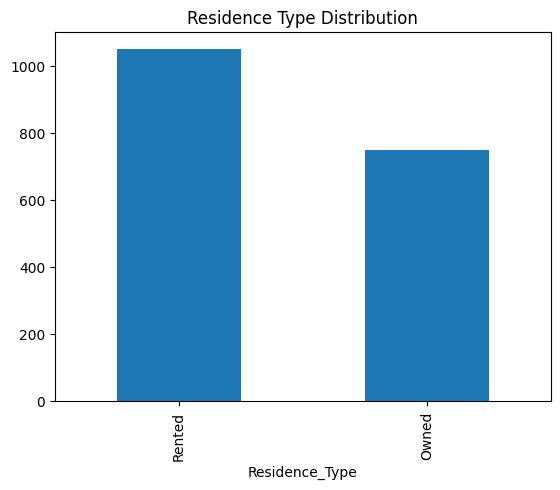

In [66]:
df['Residence_Type'].value_counts().plot(kind='bar')
plt.title("Residence Type Distribution")
plt.show()

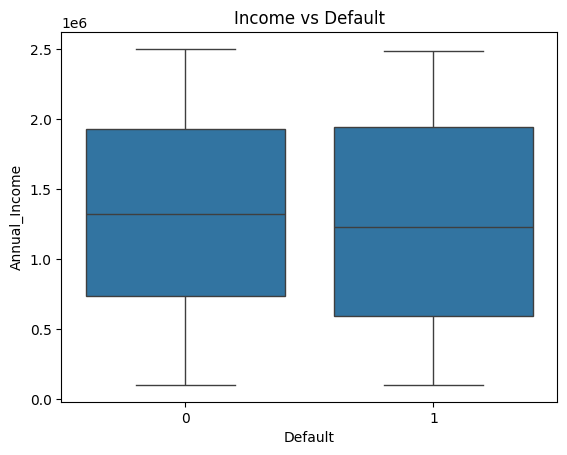

In [67]:
sns.boxplot(x='Default', y='Annual_Income', data=df)
plt.title("Income vs Default")
plt.show()

## EDA Summary

- Dataset contains both numerical and categorical variables.
- Income, credit score, and debt-to-income ratio are important financial features.
- The target variable (Default) is imbalanced.
- No missing values were found in the dataset.
- Outliers exist in financial features such as income.
- Employment type and residence type show categorical variation.

In [68]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

In [69]:
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [70]:
df = pd.get_dummies(df, drop_first=True)

In [71]:
X = df.drop('Default', axis=1)
y = df['Default']

In [72]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [73]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [74]:
print("Missing values after preprocessing:")
df.isnull().sum()

Missing values after preprocessing:


Age                              0
Years_of_Employment              0
Annual_Income                    0
Savings_Balance                  0
Bank_Balance                     0
Credit_Score                     0
Debt_to_Income_Ratio             0
Existing_Loans_Count             0
Loan_Amount_Requested            0
Loan_Term                        0
Missed_Payments                  0
Num_of_Credit_Inquiries          0
Credit_Card_Utilization          0
Dependents_Count                 0
Default                          0
Employment_Type_Self-Employed    0
Employment_Type_Unemployed       0
Residence_Type_Rented            0
dtype: int64

## Preprocessing Status

All preprocessing steps were applied successfully. Missing values were handled, categorical variables were encoded, and dataset is now clean and ready for modeling.

## Phase 1 Summary

- Exploratory Data Analysis was performed to understand dataset distribution and relationships.
- Target variable was found to be imbalanced.
- Income, age, and credit score distributions were analyzed.
- Outliers were detected using boxplots.
- Correlation matrix was used to understand feature relationships.
- Missing values were handled using median and mode imputation.
- Categorical variables were encoded using one-hot encoding.
- Features were scaled using StandardScaler.
- Dataset was split into training and testing sets.